<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
    <h1 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:2.2em; margin:0 0 8px 0;">
        Introdução ao Aprendizado de Máquina
    </h1>
    <h2 style="color:#a8d8ea; font-family:'Segoe UI', sans-serif; font-size:1.3em; margin:0 0 6px 0; font-weight:400;">
        Aula 03 — Aprendizado de Máquina: Fundamentos
    </h2>
    <h3 style="color:#e2b96f; font-family:'Segoe UI', sans-serif; font-size:1.05em; margin:0 0 12px 0; font-weight:500;">
        Prática — Preparando o Titanic para o Primeiro Modelo
    </h3>
    <p style="color:#ccc; font-family:'Segoe UI', sans-serif; font-size:0.9em; margin:0;">
        Prof. Felipe Amaral
    </p>
</div>

<div style="display:flex; gap:10px; margin-top:10px; flex-wrap:wrap;">
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">FIAP</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;">Python 3</span>
    <span style="background:#0f3460; color:#a8d8ea; padding:5px 14px; border-radius:20px; font-size:0.85em;" Dataset Titanic</span>
</div>


## Onde estamos na jornada?

Na aula anterior exploramos, limpamos e visualizamos os dados do Titanic.
Hoje damos o próximo passo: **preparar esses dados para receber um modelo de Machine Learning**.

Nenhum modelo será treinado hoje — isso vem na próxima aula.
O que vamos fazer é igualmente importante: garantir que os dados estejam no formato certo,
com as informações certas, para que o modelo possa aprender da melhor forma possível.

> *"Um modelo só é tão bom quanto os dados que recebe."*

---

## O que vamos aprender hoje

| Parte | Tema |
|-------|------|
| **1** | Os 3 paradigmas — reconhecendo o tipo de problema |
| **2** | O pipeline de ML — o mapa da nossa jornada |
| **3** | Feature Engineering — criando informação nova |
| **4** | Normalização — colocando tudo na mesma escala |
| **5** | Encoding — traduzindo texto para números |
| **6** | Divisão treino/teste — separando o que o modelo vai ver |
| **7** | O dataset final — pronto para a próxima aula |

<div style="background:#d1ecf1; border-left:5px solid #0c5460; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#0c5460;">ℹ️ </strong><span style="color:#0c5460;">Este notebook continua de onde paramos no Titanic. O dataset será recarregado e relimpado automaticamente na célula de configuração abaixo — você não precisa ter o notebook anterior aberto.</span></div>

---

## Configuração — Execute antes de começar


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":  (10, 5),
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.titlesize":     13,
    "axes.labelsize":     11,
})
sns.set_theme(style="whitegrid", palette="muted")

#  Recarregando e relimpando o Titanic (mesmas etapas da aula anterior)
df_raw = sns.load_dataset("titanic")

df = df_raw.copy()
df["age"]      = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])
df = df.drop_duplicates()

print("Dataset carregado e limpo!")
print(f"   Shape: {df.shape}  ({df.shape[0]} passageiros, {df.shape[1]} colunas)")
print(f"   NaN restantes: {df.isnull().sum().sum()}")
print(f"\nColunas disponíveis:")
for col in df.columns:
    print(f"   {col:<20} {df[col].dtype}")


Dataset carregado e limpo!
   Shape: (775, 14)  (775 passageiros, 14 colunas)
   NaN restantes: 2

Colunas disponíveis:
   survived             int64
   pclass               int64
   sex                  object
   age                  float64
   sibsp                int64
   parch                int64
   fare                 float64
   embarked             object
   class                category
   who                  object
   adult_male           bool
   embark_town          object
   alive                object
   alone                bool


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 1</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Os 3 Paradigmas — Reconhecendo o Tipo de Problema</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Antes de qualquer código, precisamos saber que tipo de problema estamos resolvendo."</p></div></div></div>


### Por que isso importa?

Escolher errado o paradigma é como usar uma chave de fenda para pregar um prego.
Cada paradigma tem algoritmos, métricas e abordagens completamente diferentes.

```
APRENDIZADO DE MÁQUINA
│
├── SUPERVISIONADO  → temos dados com respostas conhecidas (rótulos)
│   ├── Classificação  → a resposta é uma CATEGORIA  (spam/não-spam)
│   └── Regressão      → a resposta é um NÚMERO      (preço, temperatura)
│
├── NÃO-SUPERVISIONADO → não temos rótulos, queremos descobrir padrões
│   ├── Clustering         → agrupar exemplos similares
│   └── Redução de dim.    → simplificar sem perder informação
│
└── POR REFORÇO → agente aprende por tentativa e erro com recompensas
    └── Jogos, robótica, veículos autônomos
```

O **Titanic é um problema de classificação supervisionada**:
- Entrada X: características do passageiro (idade, classe, gênero...)
- Saída Y: sobreviveu (1) ou não (0) — um rótulo que já conhecemos


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 1 — Para cada problema abaixo, identifique: (a) o paradigma e (b) se é classificação ou regressão. Escreva suas respostas na célula de texto abaixo.</span></div>

### Problemas para classificar:

| # | Problema | Paradigma | Classificação ou Regressão? |
|---|----------|-----------|---------------------------|
| 1 | Um banco quer saber se um cliente vai pagar ou calotear o empréstimo | ??? | ??? |
| 2 | Um e-commerce quer agrupar clientes com comportamentos similares de compra | ??? | ??? |
| 3 | Um app quer prever o tempo de entrega de um pedido em minutos | ??? | ??? |
| 4 | Um hospital quer classificar exames de mamografia como benigno ou maligno | ??? | ??? |
| 5 | Um robô aprende a andar sem cair, recebendo pontos a cada passo bem-sucedido | ??? | ??? |
| 6 | Uma imobiliária quer estimar o preço de venda de um apartamento | ??? | ??? |

*✏️ Preencha a tabela acima com suas respostas*


### O Titanic no mapa

Vamos confirmar na prática: nosso Y (`survived`) é binário — só tem os valores 0 e 1.
Isso o torna um problema de **classificação binária supervisionada**.


Distribuição da variável alvo 'survived':
survived
0    455
1    320
Name: count, dtype: int64

Valores únicos: [np.int64(0), np.int64(1)]
Tipo da coluna: int64


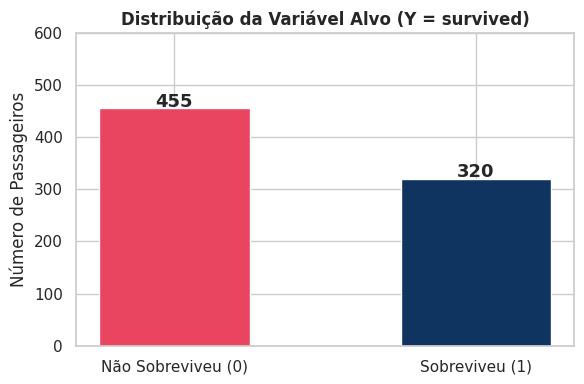


✅ Problema: Classificação Binária Supervisionada
   Y tem 2 classes: 0 (não sobreviveu) e 1 (sobreviveu)
   Dataset está levemente desbalanceado: 59% vs 41%


In [31]:
# Confirmando o tipo do nosso problema
print("Distribuição da variável alvo 'survived':")
print(df["survived"].value_counts())
print(f"\nValores únicos: {sorted(df['survived'].unique())}")
print(f"Tipo da coluna: {df['survived'].dtype}")

# Visualizando
fig, ax = plt.subplots(figsize=(6, 4))
cores = ["#e94560", "#0f3460"]
contagem = df["survived"].value_counts().sort_index()
barras = ax.bar(["Não Sobreviveu (0)", "Sobreviveu (1)"],
                contagem.values, color=cores, edgecolor="white", width=0.5)
for b, v in zip(barras, contagem.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3,
            str(v), ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Número de Passageiros")
ax.set_title("Distribuição da Variável Alvo (Y = survived)", fontweight="bold")
ax.set_ylim(0, 600)
plt.tight_layout(); plt.show()

print(f"\n✅ Problema: Classificação Binária Supervisionada")
print(f"   Y tem 2 classes: 0 (não sobreviveu) e 1 (sobreviveu)")
print(f"   Dataset está levemente desbalanceado: {contagem[0]/len(df):.0%} vs {contagem[1]/len(df):.0%}")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 2</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">O Pipeline de ML — O Mapa da Nossa Jornada</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Saber onde você está no processo evita perder tempo na etapa errada."</p></div></div></div>


### As 6 Etapas de todo projeto de ML

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    PIPELINE DE MACHINE LEARNING                         │
│                                                                         │
│  1. COLETA          2. EDA              3. PRÉ-PROCESSAMENTO            │
│  ┌──────────┐      ┌──────────┐        ┌──────────────────────┐        │
│  │ Reunir   │ ───▶ │ Explorar │ ──────▶│ Limpar, normalizar,  │        │
│  │ os dados │      │ e entender│        │ encodar, eng. feat.  │        │
│  └──────────┘      └──────────┘        └──────────────────────┘        │
│                                                      │                  │
│                                                      ▼                  │
│  6. MONITORAR       5. AVALIAR          4. TREINAR                     │
│  ┌──────────┐      ┌──────────┐        ┌──────────────────────┐        │
│  │ Acompanhar│◀─── │ Métricas │ ◀───── │    Algoritmo de ML   │        │
│  │ em produção│     │ e ajustes│        │  (próxima aula! 🔜)  │        │
│  └──────────┘      └──────────┘        └──────────────────────┘        │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

### Onde estamos hoje

| Etapa | Status | O que fizemos/faremos |
|-------|--------|----------------------|
| 1. Coleta | ✅ Feito | Dataset carregado do Seaborn |
| 2. EDA | ✅ Feito | Aula anterior — exploração e visualização |
| 3. Pré-processamento | 🔄 **Hoje** | Limpeza, feature engineering, normalização, encoding, split |
| 4. Treinamento | 🔜 Próxima aula | Algoritmos de classificação |
| 5. Avaliação | 🔜 Próxima aula | Métricas, matriz de confusão, ROC |
| 6. Monitoramento | 🔜 Futuro | Deploy e acompanhamento |

<div style="background:#e8d5f5; border-left:5px solid #5b2c8d; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#5b2c8d;">💡 </strong><span style="color:#5b2c8d;">A etapa 3 (pré-processamento) costuma consumir <strong>70-80% do tempo</strong> de um projeto real de ML. Não é a parte mais glamourosa, mas é onde a qualidade do modelo é determinada.</span></div>


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 3</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Feature Engineering — Criando Informação Nova</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Os melhores atributos não vêm prontos no dataset — você os cria."</p></div></div></div>


### O que é Feature Engineering?

É a criação de **novos atributos a partir dos dados brutos**, usando conhecimento do domínio.

> *"Modelo simples + ótimas features quase sempre vence modelo complexo + features ruins."*

O dataset do Titanic tem colunas brutas como `sibsp` (irmãos/cônjuges) e `parch` (pais/filhos).
Separadas, essas informações são difíceis de interpretar. Combinadas, revelam algo mais rico:
**o tamanho da família do passageiro** — e famílias grandes talvez tenham tido dificuldade
de embarcar nos botes salva-vidas.

Vamos criar 5 features novas.

---

### Feature 1 — Tamanho da Família


Distribuição do tamanho de família:
tamanho_familia
1     437
2     154
3     101
4      28
5      13
6      22
7      12
8       6
11      2


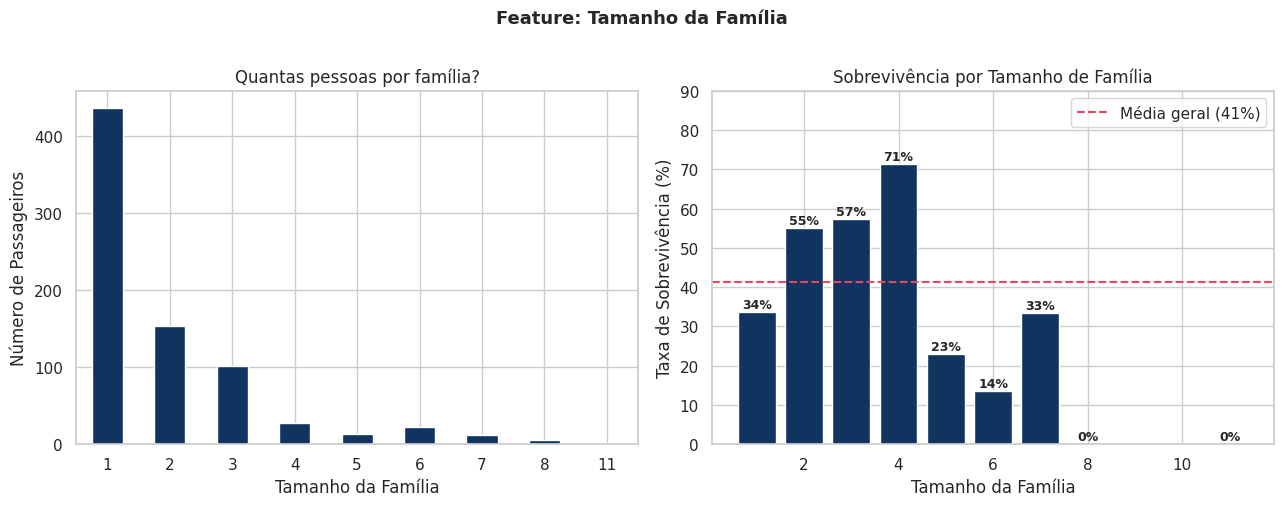


💬 Famílias médias (2-4) sobreviveram mais que viajantes sozinhos ou famílias grandes?


In [32]:
# Feature 1: tamanho total da família a bordo
# sibsp = irmãos + cônjuge | parch = pais + filhos | +1 = o próprio passageiro
df["tamanho_familia"] = df["sibsp"] + df["parch"] + 1

print("Distribuição do tamanho de família:")
print(df["tamanho_familia"].value_counts().sort_index().to_string())

# Relação com sobrevivência
taxa_familia = df.groupby("tamanho_familia")["survived"].mean() * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Distribuição
df["tamanho_familia"].value_counts().sort_index().plot(
    kind="bar", ax=ax1, color="#0f3460", edgecolor="white")
ax1.set_xlabel("Tamanho da Família")
ax1.set_ylabel("Número de Passageiros")
ax1.set_title("Quantas pessoas por família?")
ax1.tick_params(axis="x", rotation=0)

# Taxa de sobrevivência por tamanho
barras = ax2.bar(taxa_familia.index, taxa_familia.values,
                  color="#0f3460", edgecolor="white")
for b, v in zip(barras, taxa_familia.values):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
ax2.axhline(df["survived"].mean()*100, color="#e94560",
            linestyle="--", label=f"Média geral ({df['survived'].mean()*100:.0f}%)")
ax2.set_xlabel("Tamanho da Família")
ax2.set_ylabel("Taxa de Sobrevivência (%)")
ax2.set_title("Sobrevivência por Tamanho de Família")
ax2.set_ylim(0, 90); ax2.legend()

plt.suptitle("Feature: Tamanho da Família", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

print("\n💬 Famílias médias (2-4) sobreviveram mais que viajantes sozinhos ou famílias grandes?")


---

### Feature 2 — Viajando Sozinho?


Taxa de sobrevivência:
  Acompanhado: 51.2%
  Sozinho:     33.6%
  Total sozinhos: 437 passageiros (56%)


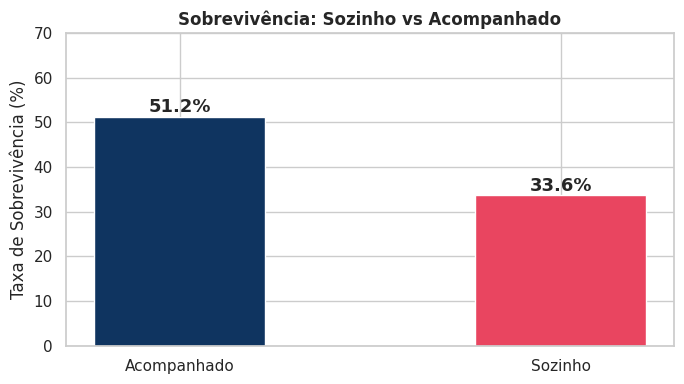

In [33]:
# Feature 2: passageiro estava sozinho (sem família a bordo)?
df["sozinho"] = (df["tamanho_familia"] == 1).astype(int)

taxa_sozinho = df.groupby("sozinho")["survived"].mean() * 100
print("Taxa de sobrevivência:")
print(f"  Acompanhado: {taxa_sozinho[0]:.1f}%")
print(f"  Sozinho:     {taxa_sozinho[1]:.1f}%")
print(f"  Total sozinhos: {df['sozinho'].sum()} passageiros ({df['sozinho'].mean():.0%})")

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(["Acompanhado", "Sozinho"],
                [taxa_sozinho[0], taxa_sozinho[1]],
                color=["#0f3460", "#e94560"], edgecolor="white", width=0.45)
for b, v in zip(barras, [taxa_sozinho[0], taxa_sozinho[1]]):
    ax.text(b.get_x() + b.get_width()/2, v + 1,
            f"{v:.1f}%", ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Taxa de Sobrevivência (%)")
ax.set_title("Sobrevivência: Sozinho vs Acompanhado", fontweight="bold")
ax.set_ylim(0, 70)
plt.tight_layout(); plt.show()


---

### Feature 3 — Faixa Etária


In [34]:
# Feature 3: faixa etária categorizada
def classificar_idade(age):
    if age < 12:   return "Criança"
    elif age < 18: return "Adolescente"
    elif age < 60: return "Adulto"
    else:          return "Idoso"

df["faixa_etaria"] = df["age"].apply(classificar_idade)

# Definindo a ordem (vai ser útil no encoding depois)
ordem_faixa = ["Criança", "Adolescente", "Adulto", "Idoso"]

print("Distribuição por faixa etária:")
for faixa in ordem_faixa:
    n = (df["faixa_etaria"] == faixa).sum()
    taxa = df[df["faixa_etaria"] == faixa]["survived"].mean() * 100
    print(f"  {faixa:<15} {n:>4} passageiros  |  sobrevivência: {taxa:.1f}%")


Distribuição por faixa etária:
  Criança           67 passageiros  |  sobrevivência: 56.7%
  Adolescente       43 passageiros  |  sobrevivência: 51.2%
  Adulto           640 passageiros  |  sobrevivência: 39.5%
  Idoso             25 passageiros  |  sobrevivência: 28.0%


---

### Feature 4 — Tarifa por Pessoa

A tarifa bruta (`fare`) pode ser paga por uma família inteira. Dividida pelo tamanho da família,
temos o valor real pago por pessoa — uma medida mais justa de poder aquisitivo.


Estatísticas da tarifa por pessoa:
count    775.00
mean      21.33
std       38.02
min        0.00
25%        7.25
50%        8.75
75%       26.00
max      512.33
Name: tarifa_por_pessoa, dtype: float64


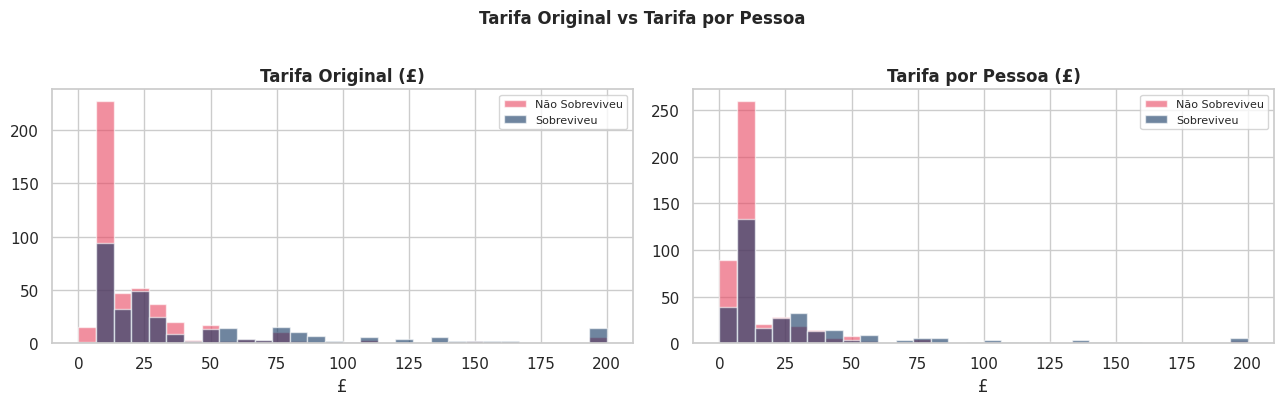

In [35]:
# Feature 5: tarifa por pessoa (evitar divisão por zero com clip)
df["tarifa_por_pessoa"] = df["fare"] / df["tamanho_familia"].clip(lower=1)
df["tarifa_por_pessoa"] = df["tarifa_por_pessoa"].round(2)

print("Estatísticas da tarifa por pessoa:")
print(df["tarifa_por_pessoa"].describe().round(2))

# Comparação: fare original vs tarifa_por_pessoa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, titulo in [
    (ax1, "fare",             "Tarifa Original (£)"),
    (ax2, "tarifa_por_pessoa","Tarifa por Pessoa (£)"),
]:
    for s, cor, lbl in [(0,"#e94560","Não Sobreviveu"),(1,"#0f3460","Sobreviveu")]:
        vals = df[df["survived"]==s][col].clip(upper=200)
        ax.hist(vals, bins=30, alpha=0.6, color=cor, label=lbl, edgecolor="white")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("£"); ax.legend(fontsize=8)

plt.suptitle("Tarifa Original vs Tarifa por Pessoa", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 2 — Crie mais uma feature de sua escolha a partir dos dados disponíveis. Pense: qual informação ainda não foi capturada? Sugestões: (a) passageiro era criança E viajava com adultos? (b) combinação de classe + gênero? Justifique por que essa feature pode ser útil.</span></div>

In [36]:
# ✏️ Crie sua feature aqui
# df["minha_feature"] = ???

# Mostre a distribuição e a taxa de sobrevivência por valor da feature
print("Implemente sua feature aqui!")


Implemente sua feature aqui!


In [37]:
# GABARITO DA MISSÃO 2 — sugestão: classe + gênero combinados
# Combinação de classe social e gênero — uma variável de interação
df["classe_genero"] = df["pclass"].astype(str) + "_" + df["sex"]
taxa_cg = df.groupby("classe_genero")["survived"].mean().sort_values(ascending=False) * 100
print("Taxa de sobrevivência por Classe × Gênero:")
print(taxa_cg.to_string())
print("\n💡 '1_female' (mulher 1ª classe) tem a maior taxa.")
print("   '3_male'   (homem 3ª classe) tem a menor taxa.")
print("   Esta feature captura a interação entre as duas variáveis!")


Taxa de sobrevivência por Classe × Gênero:
classe_genero
1_female    96.774194
2_female    91.666667
3_female    47.244094
1_male      36.752137
2_male      18.478261
3_male      16.058394

💡 '1_female' (mulher 1ª classe) tem a maior taxa.
   '3_male'   (homem 3ª classe) tem a menor taxa.
   Esta feature captura a interação entre as duas variáveis!


In [38]:
# Resumo das features criadas
novas_features = ["tamanho_familia", "sozinho", "faixa_etaria", "tarifa_por_pessoa"]
print("RESUMO — Features Criadas")
print("=" * 50)
print(f"{'Feature':<22} {'Tipo':<12} {'Valores únicos'}")
print("-" * 50)
for feat in novas_features:
    tipo  = str(df[feat].dtype)
    n_uni = df[feat].nunique()
    print(f"  {feat:<20} {tipo:<12} {n_uni}")
print(f"\nDataset: era {df_raw.shape[1]-1} colunas → agora {df.shape[1]-1} colunas úteis")


RESUMO — Features Criadas
Feature                Tipo         Valores únicos
--------------------------------------------------
  tamanho_familia      int64        9
  sozinho              int64        2
  faixa_etaria         object       4
  tarifa_por_pessoa    float64      270

Dataset: era 14 colunas → agora 18 colunas úteis


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 4</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Normalização — Colocando Tudo na Mesma Escala</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Sem normalização, variáveis maiores dominam o modelo injustamente."</p></div></div></div>


### O Problema das Escalas Diferentes

Veja as escalas das nossas variáveis numéricas:


In [39]:
# Visualizando o problema de escala
colunas_num = ["age", "fare", "tamanho_familia", "tarifa_por_pessoa", "pclass"]

print("Escalas das variáveis numéricas:")
print("=" * 55)
print(f"{'Coluna':<22} {'Mínimo':>8} {'Máximo':>10} {'Média':>10}")
print("-" * 55)
for col in colunas_num:
    print(f"  {col:<20} {df[col].min():>8.1f} {df[col].max():>10.1f} {df[col].mean():>10.1f}")

print("\n⚠️  Problema: 'fare' vai até 512, enquanto 'tamanho_familia' vai até 11.")
print("   Algoritmos baseados em distância (ex: KNN) vão ignorar 'tamanho_familia'")
print("   porque o efeito numérico de 'fare' é muito maior!")


Escalas das variáveis numéricas:
Coluna                   Mínimo     Máximo      Média
-------------------------------------------------------
  age                       0.4       80.0       29.6
  fare                      0.0      512.3       34.9
  tamanho_familia           1.0       11.0        1.9
  tarifa_por_pessoa         0.0      512.3       21.3
  pclass                    1.0        3.0        2.2

⚠️  Problema: 'fare' vai até 512, enquanto 'tamanho_familia' vai até 11.
   Algoritmos baseados em distância (ex: KNN) vão ignorar 'tamanho_familia'
   porque o efeito numérico de 'fare' é muito maior!


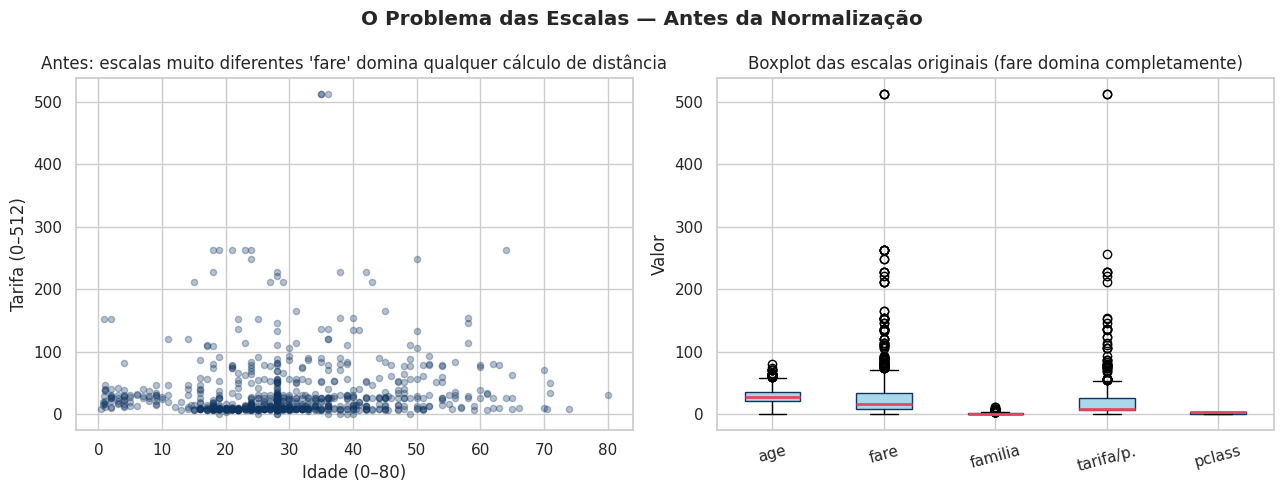

In [40]:
# Demonstração visual do problema
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("O Problema das Escalas — Antes da Normalização", fontweight="bold")

# Gráfico de dispersão com escalas originais
axes[0].scatter(df["age"], df["fare"], alpha=0.3, color="#0f3460", s=20)
axes[0].set_xlabel("Idade (0–80)")
axes[0].set_ylabel("Tarifa (0–512)")
axes[0].set_title("Antes: escalas muito diferentes 'fare' domina qualquer cálculo de distância")

# Box plots comparando escalas
dados_box = [df[col].values for col in ["age", "fare", "tamanho_familia",
                                          "tarifa_por_pessoa", "pclass"]]
axes[1].boxplot(dados_box, labels=["age", "fare", "familia", "tarifa/p.", "pclass"],
                patch_artist=True,
                boxprops=dict(facecolor="#a8d8ea", color="#0f3460"),
                medianprops=dict(color="#e94560", linewidth=2))
axes[1].set_ylabel("Valor")
axes[1].set_title("Boxplot das escalas originais (fare domina completamente)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()


### Os Dois Principais Métodos

| Método | Fórmula | Resultado | Quando usar |
|--------|---------|-----------|-------------|
| **Min-Max** | (x − min) / (max − min) | Valores entre [0, 1] | Quando os limites são conhecidos e não há outliers extremos |
| **Z-score** | (x − média) / desvio_padrão | Média=0, Desvio=1 | Distribuição aproximadamente normal |

<div style="background:#f8d7da; border-left:5px solid #721c24; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#721c24;">🚨 </strong><span style="color:#721c24;">Regra crítica: o scaler deve ser <strong>ajustado (fit) apenas nos dados de treino</strong> e depois aplicado ao teste. Caso contrário, informação do teste vaza para o treino — isso se chama <strong>data leakage</strong> e invalida a avaliação do modelo. Veremos isso na prática na Parte 6.</span></div>


In [41]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

colunas_normalizar = ["age", "fare", "tamanho_familia", "tarifa_por_pessoa"]

# ── Aplicando os dois métodos ─────────────────────────────────────────────────
minmax = MinMaxScaler()
zscore = StandardScaler()

df_minmax = df[colunas_normalizar].copy()
df_zscore = df[colunas_normalizar].copy()

df_minmax[colunas_normalizar] = minmax.fit_transform(df[colunas_normalizar])
df_zscore[colunas_normalizar] = zscore.fit_transform(df[colunas_normalizar])

# Comparação
print("COMPARAÇÃO: Original vs Min-Max vs Z-score")
print("=" * 65)
print(f"{'Coluna':<20} {'Orig. Min':>9} {'Orig. Max':>9} {'MM Min':>8} {'MM Max':>8} {'ZS Média':>9} {'ZS Std':>8}")
print("-" * 65)
for col in colunas_normalizar:
    print(f"  {col:<18} {df[col].min():>9.1f} {df[col].max():>9.1f} "
          f"{df_minmax[col].min():>8.3f} {df_minmax[col].max():>8.3f} "
          f"{df_zscore[col].mean():>9.3f} {df_zscore[col].std():>8.3f}")


COMPARAÇÃO: Original vs Min-Max vs Z-score
Coluna               Orig. Min Orig. Max   MM Min   MM Max  ZS Média   ZS Std
-----------------------------------------------------------------
  age                      0.4      80.0    0.000    1.000     0.000    1.001
  fare                     0.0     512.3    0.000    1.000    -0.000    1.001
  tamanho_familia          1.0      11.0    0.000    1.000    -0.000    1.001
  tarifa_por_pessoa        0.0     512.3    0.000    1.000     0.000    1.001


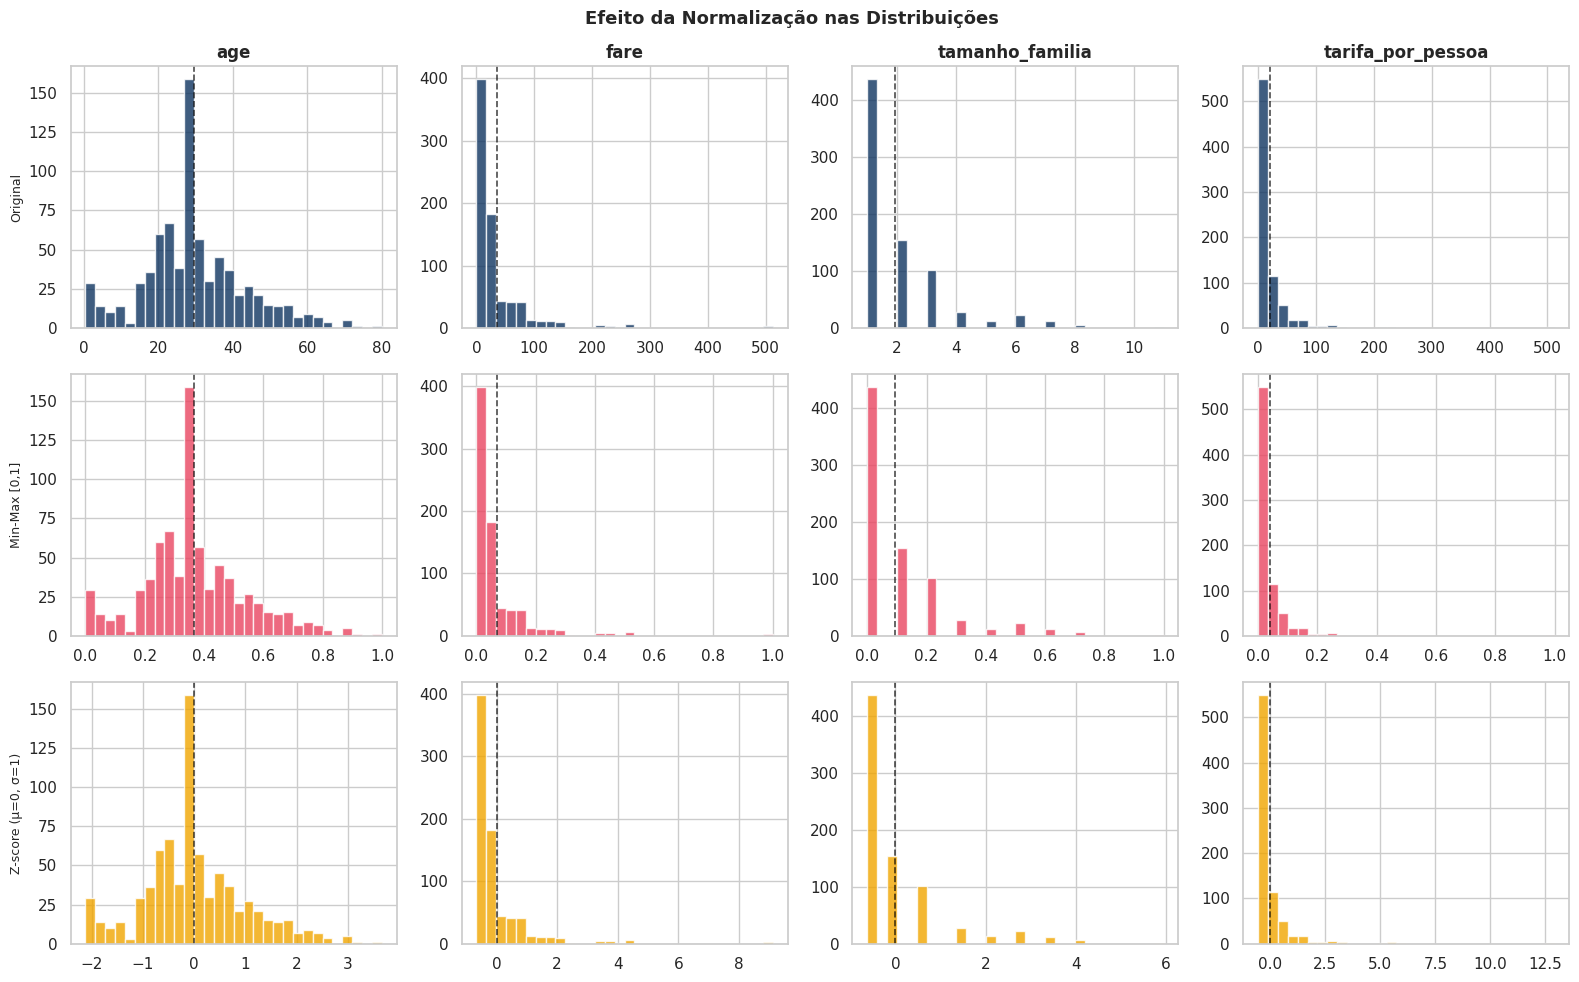

💡 Nota: a FORMA da distribuição não muda — apenas a escala muda!


In [42]:
# Visualização: antes e depois da normalização
fig, axes = plt.subplots(3, len(colunas_normalizar), figsize=(16, 10))
fig.suptitle("Efeito da Normalização nas Distribuições", fontsize=13, fontweight="bold")

titulos_linha = ["Original", "Min-Max [0,1]", "Z-score (μ=0, σ=1)"]
datasets      = [df, df_minmax, df_zscore]
cor_por_linha = ["#0f3460", "#e94560", "#f0a500"]

for linha, (titulo, dados, cor) in enumerate(zip(titulos_linha, datasets, cor_por_linha)):
    for col_idx, col in enumerate(colunas_normalizar):
        ax = axes[linha, col_idx]
        ax.hist(dados[col], bins=30, color=cor, alpha=0.8, edgecolor="white")
        if linha == 0: ax.set_title(col, fontweight="bold")
        if col_idx == 0: ax.set_ylabel(titulo, fontsize=9)
        media = dados[col].mean()
        ax.axvline(media, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

plt.tight_layout()
plt.savefig("aula04_normalizacao.png", dpi=110, bbox_inches="tight")
plt.show()
print("💡 Nota: a FORMA da distribuição não muda — apenas a escala muda!")


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 3 — Qual método você escolheria para a coluna <code>fare</code> do Titanic e por quê? Dica: execute <code>df['fare'].describe()</code> e observe a diferença entre média e mediana. O que isso indica sobre a distribuição? Registre sua resposta na célula abaixo.</span></div>

*✏️ Minha escolha para normalizar 'fare': ???*

*Justificativa: ???*


In [43]:
# ── GABARITO DA MISSÃO 3 (descomente para ver) ───────────────────────────────
# print(df["fare"].describe().round(2))
# print()
# print("Análise:")
# media   = df["fare"].mean()
# mediana = df["fare"].median()
# print(f"  Média:   {media:.2f}")
# print(f"  Mediana: {mediana:.2f}")
# print(f"  Razão:   {media/mediana:.1f}x maior")
# print()
# print("Conclusão: média é MUITO maior que mediana → distribuição assimétrica com outliers.")
# print("→ Z-score é melhor pois lida bem com assimetria.")
# print("→ Ou ainda melhor: RobustScaler (usa mediana e IQR) — resistente a outliers.")
# print()
# print("Min-Max seria problemático aqui: o passageiro que pagou £512 comprimiria")
# print("todos os outros passageiros para próximo de zero.")


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 5</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Encoding — Traduzindo Texto para Números</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Algoritmos só entendem números — mas podemos traduzir sem perder significado."</p></div></div></div>


### Por que precisamos de encoding?

Algoritmos de ML são operações matemáticas. Eles não conseguem calcular
a distância entre `"masculino"` e `"feminino"` — mas conseguem entre `0` e `1`.

Existem dois tipos de variável categórica e cada um exige um tratamento diferente:

```
Variáveis Categóricas
│
├── ORDINAIS → têm ordem natural
│   Exemplos: escolaridade (Fund < Médio < Superior)
│             faixa etária (Criança < Adolescente < Adulto < Idoso)
│             nível de satisfação (Ruim < Regular < Bom < Ótimo)
│   Método: LABEL ENCODING (mapear para inteiros preservando a ordem)
│
└── NOMINAIS → não têm ordem natural
    Exemplos: cidade (SP, RJ, BH — nenhuma é "maior" que outra)
              porto de embarque (S, C, Q)
              cor favorita
    Método: ONE-HOT ENCODING (criar uma coluna binária por categoria)
```


---

### Encoding 1 — Label Encoding para variáveis ordinais


In [44]:
# Label Encoding: faixa_etaria (tem ordem: Criança < Adolescente < Adulto < Idoso)
ordem_faixa = {"Criança": 0, "Adolescente": 1, "Adulto": 2, "Idoso": 3}
df["faixa_etaria_enc"] = df["faixa_etaria"].map(ordem_faixa)

print("Label Encoding — faixa_etaria:")
resultado = df[["faixa_etaria", "faixa_etaria_enc"]].drop_duplicates().sort_values("faixa_etaria_enc")
print(resultado.to_string(index=False))
print()

# sex: variável binária — 0 e 1 são suficientes
df["sex_enc"] = (df["sex"] == "female").astype(int)
print("Label Encoding — sex (binário):")
print(df[["sex","sex_enc"]].drop_duplicates().sort_values("sex_enc").to_string(index=False))


Label Encoding — faixa_etaria:
faixa_etaria  faixa_etaria_enc
     Criança                 0
 Adolescente                 1
      Adulto                 2
       Idoso                 3

Label Encoding — sex (binário):
   sex  sex_enc
  male        0
female        1


---

### Encoding 2 — One-Hot Encoding para variáveis nominais


In [45]:
# One-Hot Encoding: embarked (S, C, Q — sem ordem)
# drop_first=True: remove uma coluna para evitar multicolinearidade
embarked_ohe = pd.get_dummies(df["embarked"], prefix="embarked", drop_first=True)

print("One-Hot Encoding — embarked:")
print("Original:")
print(df["embarked"].value_counts().to_string())
print("\nApós OHE (primeiras linhas):")
print(embarked_ohe.head(8).to_string())
print(f"\n→ 3 categorias → 2 colunas binárias (drop_first evita redundância)")


One-Hot Encoding — embarked:
Original:
embarked
S    562
C    155
Q     58

Após OHE (primeiras linhas):
   embarked_Q  embarked_S
0       False        True
1       False       False
2       False        True
3       False        True
4       False        True
5        True       False
6       False        True
7       False        True

→ 3 categorias → 2 colunas binárias (drop_first evita redundância)


<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO 4 — Decida o encoding correto para a coluna <code>pclass</code> (1, 2, 3): Label Encoding ou One-Hot? Justifique considerando: pclass tem ordem? O que significaria dizer que '3ª classe é 3x maior que 1ª'? Registre sua resposta abaixo.</span></div>

*✏️ Meu encoding para pclass: ???*

*Justificativa: ???*


In [46]:
# ── GABARITO DA MISSÃO 4 (descomente para ver) ───────────────────────────────
print("Análise de pclass:")
print(df["pclass"].value_counts().sort_index())
print()
print("Debate:")
print("  ARGUMENTO Label Encoding: pclass TEM ordem (1 > 2 > 3 em qualidade).")
print("  Podemos mapear: 1→2, 2→1, 3→0 (invertendo para 0=pior, 2=melhor).")
print()
print("  ARGUMENTO One-Hot: a diferença entre classes não é linear.")
print("  A diferença 1ª→2ª não é igual a 2ª→3ª em termos de preço e sobrevivência.")
print()
print("Na prática: ambas as abordagens são usadas.")
print("Label Encoding é mais comum por simplicidade.")
print("One-Hot é mais seguro para modelos lineares.")
print()
# Usando Label Encoding com inversão (0=pior, 2=melhor)
df["pclass_enc"] = df["pclass"].map({1: 2, 2: 1, 3: 0})
print("Resultado com Label Encoding (invertido):")
print(df[["pclass","pclass_enc"]].drop_duplicates().sort_values("pclass"))


Análise de pclass:
pclass
1    210
2    164
3    401
Name: count, dtype: int64

Debate:
  ARGUMENTO Label Encoding: pclass TEM ordem (1 > 2 > 3 em qualidade).
  Podemos mapear: 1→2, 2→1, 3→0 (invertendo para 0=pior, 2=melhor).

  ARGUMENTO One-Hot: a diferença entre classes não é linear.
  A diferença 1ª→2ª não é igual a 2ª→3ª em termos de preço e sobrevivência.

Na prática: ambas as abordagens são usadas.
Label Encoding é mais comum por simplicidade.
One-Hot é mais seguro para modelos lineares.

Resultado com Label Encoding (invertido):
   pclass  pclass_enc
1       1           2
9       2           1
0       3           0


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 6</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">Divisão Treino/Teste — O que o Modelo Pode Ver</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Nunca avalie um modelo nos dados que ele usou para aprender."</p></div></div></div>


### A Analogia da Prova

Imagine que você vai fazer uma prova de matemática.
Se o professor te desse as questões da prova para estudar, você tiraria 10 — mas isso
não provaria que você aprendeu de verdade.

O mesmo vale para ML:

```
DADOS COMPLETOS
│
├── TREINO (70-80%) → o modelo APRENDE aqui
│                     como os exercícios do caderno
│
└── TESTE  (20-30%) → o modelo é AVALIADO aqui
                      como a prova que você nunca viu antes
                      ⚠️ O TESTE VAI PARA A GAVETA — não tocamos até a avaliação final
```

### Por que usar `stratify`?

Nosso dataset tem ~62% de não-sobreviventes e ~38% de sobreviventes.
Se o split for aleatório puro, pode acontecer de treino e teste terem proporções diferentes —
o que desequilibraria o aprendizado.

`stratify=y` garante que **ambos os splits tenham a mesma proporção de classes**.


In [47]:
from sklearn.model_selection import train_test_split

# ── Definindo as features (X) e o alvo (y) ────────────────────────────────────
# Features que vamos usar — apenas as já processadas
features = [
    "pclass_enc",         # classe (0=3ª, 1=2ª, 2=1ª)
    "sex_enc",            # gênero (0=masculino, 1=feminino)
    "age",                # idade normalizada na próxima célula
    "tamanho_familia",    # tamanho da família
    "sozinho",            # viajava sozinho?
    "faixa_etaria_enc",   # faixa etária
    "tarifa_por_pessoa",  # tarifa por pessoa
]

X = df[features].copy()
y = df["survived"].copy()

print(f"X (features): {X.shape}")
print(f"y (alvo):     {y.shape}")
print(f"\nDistribuição do alvo:")
print(f"  0 (não sobreviveu): {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  1 (sobreviveu):     {(y==1).sum()} ({(y==1).mean():.1%})")


X (features): (775, 7)
y (alvo):     (775,)

Distribuição do alvo:
  0 (não sobreviveu): 455 (58.7%)
  1 (sobreviveu):     320 (41.3%)


In [48]:
# ── Aplicando normalização ANTES do split ─────────────────────────────────────
# Atenção: aqui estamos num caso de aprendizado — em produção,
# o scaler deve ser ajustado APENAS no treino. Veremos isso no split abaixo.

from sklearn.preprocessing import StandardScaler

colunas_para_normalizar = ["age", "tamanho_familia", "tarifa_por_pessoa"]
scaler_referencia = StandardScaler()

# Fazemos o split PRIMEIRO, depois normalizamos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,          # 80% treino, 20% teste
    random_state=42,        # semente fixa: garante reprodutibilidade
    stratify=y              # preserva proporção das classes
)

# Fit APENAS no treino — depois transformamos os dois
X_treino[colunas_para_normalizar] = scaler_referencia.fit_transform(
    X_treino[colunas_para_normalizar])
X_teste[colunas_para_normalizar]  = scaler_referencia.transform(      # só transform!
    X_teste[colunas_para_normalizar])

print("DIVISÃO TREINO / TESTE")
print("=" * 45)
print(f"Treino:  {len(X_treino)} amostras ({len(X_treino)/len(X):.0%})")
print(f"Teste:   {len(X_teste)}  amostras ({len(X_teste)/len(X):.0%})")
print()
print("Proporção do alvo em cada split (stratify funcionando):")
print(f"  Treino  — Sobreviveu: {y_treino.mean():.1%} | Não sobreviveu: {(1-y_treino).mean():.1%}")
print(f"  Teste   — Sobreviveu: {y_teste.mean():.1%}  | Não sobreviveu: {(1-y_teste).mean():.1%}")
print(f"  Original— Sobreviveu: {y.mean():.1%} | Não sobreviveu: {(1-y).mean():.1%}")


DIVISÃO TREINO / TESTE
Treino:  620 amostras (80%)
Teste:   155  amostras (20%)

Proporção do alvo em cada split (stratify funcionando):
  Treino  — Sobreviveu: 41.3% | Não sobreviveu: 58.7%
  Teste   — Sobreviveu: 41.3%  | Não sobreviveu: 58.7%
  Original— Sobreviveu: 41.3% | Não sobreviveu: 58.7%


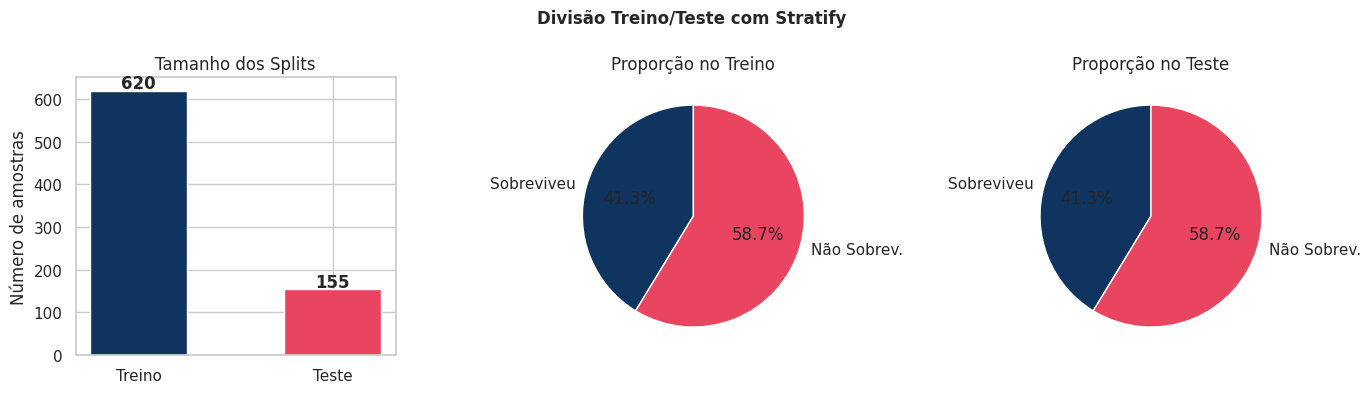

✅ Proporções iguais nos dois splits — o stratify funcionou corretamente!


In [49]:
# Visualizando o split e a distribuição do alvo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Divisão Treino/Teste com Stratify", fontsize=12, fontweight="bold")

# Tamanho dos splits
ax = axes[0]
ax.bar(["Treino", "Teste"], [len(X_treino), len(X_teste)],
       color=["#0f3460","#e94560"], edgecolor="white", width=0.5)
ax.text(0, len(X_treino)+5, str(len(X_treino)), ha="center", fontweight="bold")
ax.text(1, len(X_teste)+5,  str(len(X_teste)),  ha="center", fontweight="bold")
ax.set_title("Tamanho dos Splits")
ax.set_ylabel("Número de amostras")

# Proporção das classes no treino
ax = axes[1]
vals = [y_treino.sum(), (y_treino==0).sum()]
ax.pie(vals, labels=["Sobreviveu","Não Sobrev."],
       colors=["#0f3460","#e94560"], autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor":"white"})
ax.set_title("Proporção no Treino")

# Proporção das classes no teste
ax = axes[2]
vals = [y_teste.sum(), (y_teste==0).sum()]
ax.pie(vals, labels=["Sobreviveu","Não Sobrev."],
       colors=["#0f3460","#e94560"], autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor":"white"})
ax.set_title("Proporção no Teste")

plt.tight_layout(); plt.show()
print("✅ Proporções iguais nos dois splits — o stratify funcionou corretamente!")


In [50]:
# ── DEMONSTRAÇÃO: por que fit apenas no treino? ────────────────────────────────
# Mostra o que acontece se você fizer fit no dataset inteiro (data leakage)

import warnings; warnings.filterwarnings("ignore")

# Scaler ajustado no DATASET INTEIRO (errado!)
scaler_errado = StandardScaler()
scaler_errado.fit(X[["age"]])

# Scaler ajustado APENAS no treino (correto!)
scaler_correto = StandardScaler()
scaler_correto.fit(X_treino[["age"]])

print("DEMONSTRAÇÃO DE DATA LEAKAGE")
print("=" * 50)
print(f"Média real da idade (dataset completo): {X['age'].mean():.4f}")
print()
print("Scaler ajustado no DATASET INTEIRO (vazamento):")
print(f"  Média usada para centralizar: {scaler_errado.mean_[0]:.4f}")
print(f"  ⚠️  O scaler 'viu' os dados de teste ao ser ajustado!")
print()
print("Scaler ajustado APENAS no TREINO (correto):")
print(f"  Média usada para centralizar: {scaler_correto.mean_[0]:.4f}")
print(f"  ✅ O scaler só conhece os dados de treino — teste permanece virgem.")
print()
print("A diferença parece pequena, mas em modelos reais pode inflar")
print("artificialmente as métricas de avaliação.")


DEMONSTRAÇÃO DE DATA LEAKAGE
Média real da idade (dataset completo): 29.5812

Scaler ajustado no DATASET INTEIRO (vazamento):
  Média usada para centralizar: 29.5812
  ⚠️  O scaler 'viu' os dados de teste ao ser ajustado!

Scaler ajustado APENAS no TREINO (correto):
  Média usada para centralizar: -0.0000
  ✅ O scaler só conhece os dados de treino — teste permanece virgem.

A diferença parece pequena, mas em modelos reais pode inflar
artificialmente as métricas de avaliação.


---

<div style="background: linear-gradient(90deg, #0f3460 0%, #16213e 100%); padding:20px 25px; border-radius:10px; margin:20px 0;"><div style="display:flex; justify-content:space-between; align-items:center; flex-wrap:wrap; gap:10px;"><div><span style="color:#e2b96f; font-size:0.85em; font-weight:bold; letter-spacing:2px;">PARTE 7</span><h2 style="color:white; margin:4px 0 0 0; font-family:'Segoe UI',sans-serif;">O Dataset Final — Pronto para a Próxima Aula</h2><p style="color:#a8d8ea; margin:6px 0 0 0; font-size:0.9em;">"Você acaba de completar a etapa mais trabalhosa de um projeto de ML."</p></div></div></div>


### Resumo de tudo que fizemos

Partimos de um dataset bruto com dados sujos, texto e escalas inconsistentes.
Entregamos um dataset limpo, enriquecido e no formato que qualquer algoritmo de ML espera receber.


In [51]:
# Comparação final: antes vs depois
print("ANTES (dataset bruto)")
print("=" * 55)
print(f"  Shape:              {df_raw.shape}")
print(f"  Colunas com NaN:    {df_raw.isnull().any().sum()}")
print(f"  Colunas categóricas:{df_raw.select_dtypes('object').shape[1]}")
print(f"  Features numéricas: {df_raw.select_dtypes('number').shape[1]}")
print()
print("DEPOIS (dataset pronto para ML)")
print("=" * 55)
print(f"  Shape X_treino:     {X_treino.shape}")
print(f"  Shape X_teste:      {X_teste.shape}")
print(f"  NaN em X_treino:    {X_treino.isnull().sum().sum()}")
print(f"  NaN em X_teste:     {X_teste.isnull().sum().sum()}")
print(f"  Todas numéricas:    Sim ✅")
print(f"  Normalizado:        Sim ✅")
print(f"  Codificado:         Sim ✅")
print(f"  Split estratificado: Sim ✅")


ANTES (dataset bruto)
  Shape:              (891, 15)
  Colunas com NaN:    4
  Colunas categóricas:5
  Features numéricas: 6

DEPOIS (dataset pronto para ML)
  Shape X_treino:     (620, 7)
  Shape X_teste:      (155, 7)
  NaN em X_treino:    0
  NaN em X_teste:     0
  Todas numéricas:    Sim ✅
  Normalizado:        Sim ✅
  Codificado:         Sim ✅
  Split estratificado: Sim ✅


In [52]:
# Visualizando o dataset final
print("X_treino — primeiras 5 linhas:")
X_treino.head()


X_treino — primeiras 5 linhas:


,pclass_enc,sex_enc,age,tamanho_familia,sozinho,faixa_etaria_enc,tarifa_por_pessoa
429,0,0,0.202478,-0.600321,1,2,-0.328001
179,0,0,0.497784,-0.600321,1,2,-0.534467
672,1,0,3.007887,-0.600321,1,3,-0.265163
227,0,0,-0.646528,-0.600321,1,2,-0.348519
383,2,1,0.423957,0.049241,0,2,0.132381


In [53]:
# Sumário estatístico do dataset de treino
print("Estatísticas do X_treino (após normalização):")
X_treino.describe().round(3)


Estatísticas do X_treino (após normalização):


,pclass_enc,sex_enc,age,tamanho_familia,sozinho,faixa_etaria_enc,tarifa_por_pessoa
count,620.000,620.000,620.000,620.000,620.000,620.000,620.000
mean,0.723,0.384,-0.000,0.000,0.581,1.794,0.000
std,0.843,0.487,1.001,1.001,0.494,0.630,1.001
min,0.000,0.000,-2.111,-0.600,0.000,0.000,-0.534
25%,0.000,0.000,-0.610,-0.600,0.000,2.000,-0.349
50%,0.000,0.000,-0.093,-0.600,1.000,2.000,-0.312
75%,2.000,1.000,0.498,0.049,1.000,2.000,0.101
max,2.000,1.000,3.746,5.895,1.000,3.000,12.606


In [54]:
# Mapa visual: o que cada feature original se tornou
print("MAPA DE TRANSFORMAÇÕES")
print("=" * 60)
transformacoes = [
    ("name",      "titulo_* (OHE)",         "Extraído + OHE"),
    ("sex",       "sex_enc",                "Label Encoding (0/1)"),
    ("pclass",    "pclass_enc",             "Label Encoding (0/1/2)"),
    ("age",       "age (normalizada)",      "Preenchido mediana + Z-score"),
    ("sibsp",     "tamanho_familia",        "Engenharia: sibsp+parch+1"),
    ("parch",     "tamanho_familia",        "Engenharia: sibsp+parch+1"),
    ("fare",      "tarifa_por_pessoa",      "Engenharia: fare/familia"),
    ("embarked",  "embarked_q / embarked_s","One-Hot Encoding"),
    ("--",        "sozinho",               "Engenharia: familia==1"),
    ("--",        "faixa_etaria_enc",       "Engenharia + Label Enc."),
]
print(f"  {'Original':<15} → {'Resultado':<25} {'Técnica'}")
print("  " + "-"*58)
for orig, resultado, tecnica in transformacoes:
    print(f"  {orig:<15} → {resultado:<25} {tecnica}")
print()
print(f"  Total de features finais: {X_treino.shape[1]}")


MAPA DE TRANSFORMAÇÕES
  Original        → Resultado                 Técnica
  ----------------------------------------------------------
  name            → titulo_* (OHE)            Extraído + OHE
  sex             → sex_enc                   Label Encoding (0/1)
  pclass          → pclass_enc                Label Encoding (0/1/2)
  age             → age (normalizada)         Preenchido mediana + Z-score
  sibsp           → tamanho_familia           Engenharia: sibsp+parch+1
  parch           → tamanho_familia           Engenharia: sibsp+parch+1
  fare            → tarifa_por_pessoa         Engenharia: fare/familia
  embarked        → embarked_q / embarked_s   One-Hot Encoding
  --              → sozinho                   Engenharia: familia==1
  --              → faixa_etaria_enc          Engenharia + Label Enc.

  Total de features finais: 7


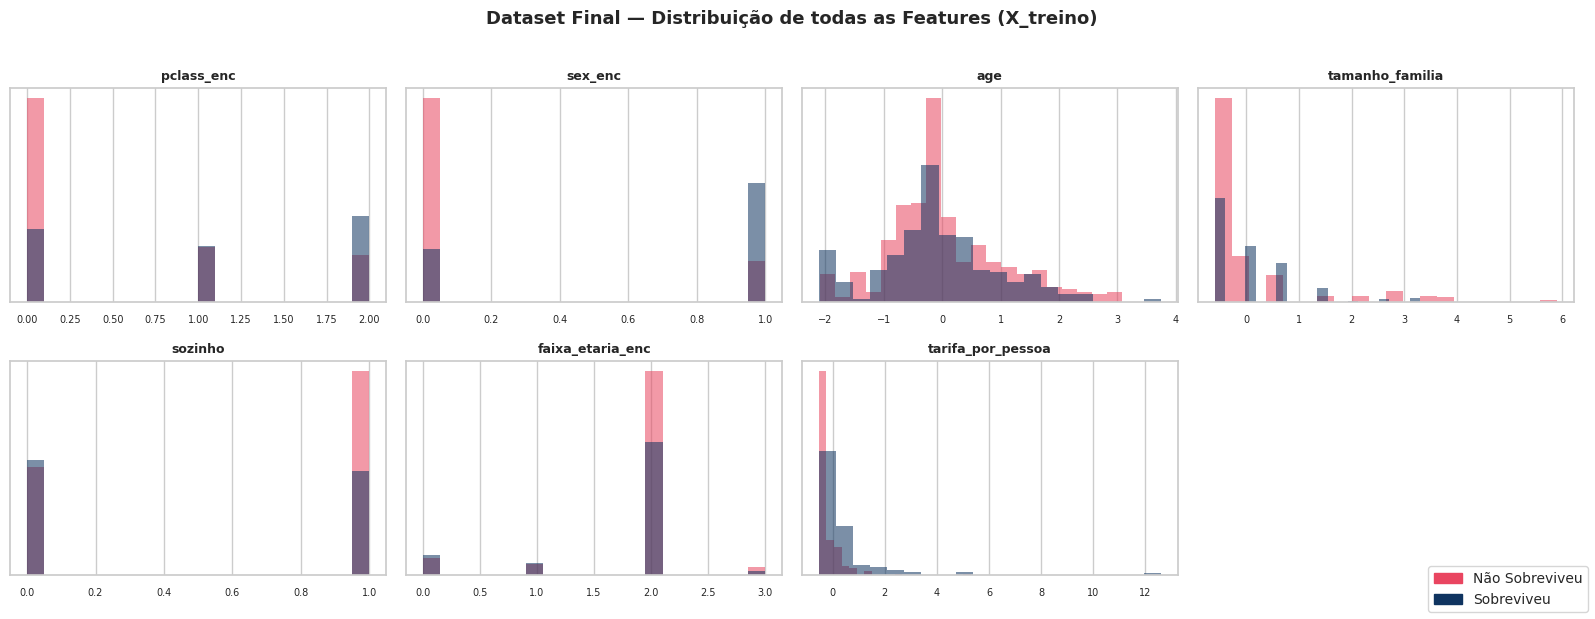

✅ Painel salvo como 'aula04_features_finais.png'


In [55]:
# Painel final de distribuições das features
n_cols = 4
n_rows = -(-X_treino.shape[1] // n_cols)   # divisão com teto

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
fig.suptitle("Dataset Final — Distribuição de todas as Features (X_treino)",
             fontsize=13, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

for i, col in enumerate(X_treino.columns):
    ax = axes_flat[i]
    # Colorir por classe: azul=sobreviveu, vermelho=não sobreviveu
    for sobrev, cor in [(0, "#e94560"), (1, "#0f3460")]:
        mask = y_treino == sobrev
        ax.hist(X_treino.loc[mask, col], bins=20, alpha=0.55, color=cor,
                edgecolor="none", label=("Não Sobrev." if sobrev==0 else "Sobreviveu"))
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_yticks([])

# Removendo subplots vazios
for j in range(len(X_treino.columns), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Legenda global
handles = [mpatches.Patch(color="#e94560", label="Não Sobreviveu"),
           mpatches.Patch(color="#0f3460", label="Sobreviveu")]
fig.legend(handles=handles, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("aula04_features_finais.png", dpi=110, bbox_inches="tight")
plt.show()
print("✅ Painel salvo como 'aula04_features_finais.png'")


---

## Checklist do Pré-processamento

Antes de passar os dados para um modelo, confirme cada etapa:

| Etapa | Aplicada? | Como verificar |
|-------|-----------|----------------|
| Valores faltantes tratados | ☐ | `X_treino.isnull().sum().sum() == 0` |
| Features novas criadas (FE) | ☐ | Lista de novas colunas no DataFrame |
| Variáveis ordinais com Label Encoding | ☐ | Mapeamento com ordem natural preservada |
| Variáveis nominais com One-Hot Encoding | ☐ | Colunas binárias por categoria |
| Normalização aplicada | ☐ | Média ≈ 0, desvio ≈ 1 (Z-score) ou valores em [0,1] |
| Scaler ajustado APENAS no treino | ☐ | `scaler.fit(X_treino)` — nunca `fit(X)` |
| Split estratificado | ☐ | Proporção das classes igual nos dois splits |
| Conjunto de teste intocado | ☐ | X_teste/y_teste usados APENAS na avaliação |

<div style="background:#fde8d8; border-left:5px solid #a04000; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#a04000;">🎯 </strong><span style="color:#a04000;">MISSÃO FINAL — Escreva na célula abaixo: (1) qual foi a etapa mais difícil de entender e por quê, (2) qual feature nova você acha que será mais útil para o modelo, e (3) o que você espera que aconteça na próxima aula quando treinarmos o primeiro modelo.</span></div>

---


**✏️ Minha reflexão:**

1. Etapa mais difícil: *...*

2. Feature mais promissora: *...* — porque: *...*

3. O que espero da próxima aula: *...*


---

## O que vem a seguir?

Na próxima aula você vai pegar exatamente o `X_treino`, `X_teste`, `y_treino` e `y_teste`
que preparamos hoje e treinar os primeiros algoritmos de classificação:

```python
# É isso que você vai escrever na próxima aula:
from sklearn.??? import ???Classifier

modelo = ???Classifier()
modelo.fit(X_treino, y_treino)          # aprende com os dados de treino
previsoes = modelo.predict(X_teste)     # prevê para dados novos
```

Toda a preparação que você fez hoje garante que esse código vai funcionar da melhor forma possível.

<div style="background:#d4edda; border-left:5px solid #155724; padding:14px 20px; border-radius:6px; margin:12px 0;"><strong style="color:#155724;">✅ </strong><span style="color:#155724;">Parabéns! Você completou a etapa de pré-processamento — a mais trabalhosa de qualquer projeto de ML. Na prática, cientistas de dados experientes passam 70-80% do tempo exatamente nessas etapas que você acaba de executar.</span></div>

---

## Referências

- Scikit-Learn Preprocessing: https://scikit-learn.org/stable/modules/preprocessing.html
- Géron, A. (2019). *Hands-on Machine Learning*, Cap. 2. O'Reilly.
- Kuhn, M. & Johnson, K. (2019). *Feature Engineering and Selection*. CRC Press. (PDF gratuito: http://www.feat.engineering/)
